<a href="https://colab.research.google.com/github/diegofuentes51/LAB08/blob/develop/LAB08_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LABORATORIO 08 - MINERIA DE DATOS

ALUMNO : DIEGO ALONSO FUENTES ARELLANO

In [1]:
#En esa parte de carga las librerias mas necesarias para desarrollar el laboratorio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [2]:
# Carga datos desde el repositorio UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"

columnas = ["id", "clump_thickness", "uniform_cell_size", "uniform_cell_shape", "marginal_adhesion",
            "single_epithelial_cell_size", "bare_nuclei", "bland_chromatin", "normal_nucleoli", "mitoses", "class"]

# Leer el dataset
df = pd.read_csv(url, header=None, names=columnas)
df.head()


,id,clump_thickness,uniform_cell_size,uniform_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [3]:
# Reemplazar ? por NaN
df.replace("?", np.nan, inplace=True)

# Convierte columnas numéricas
df["bare_nuclei"] = pd.to_numeric(df["bare_nuclei"])

# Imputa valores faltantes con la mediana
df["bare_nuclei"].fillna(df["bare_nuclei"].median(), inplace=True)

# Eliminar la columna id
df.drop("id", axis=1, inplace=True)

# Verificar que no hay NaNs
df.isnull().sum()


<ipython-input-3-11f2740082b0>:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["bare_nuclei"].fillna(df["bare_nuclei"].median(), inplace=True)


,0
clump_thickness,0
uniform_cell_size,0
uniform_cell_shape,0
marginal_adhesion,0
single_epithelial_cell_size,0
bare_nuclei,0
bland_chromatin,0
normal_nucleoli,0
mitoses,0
class,0


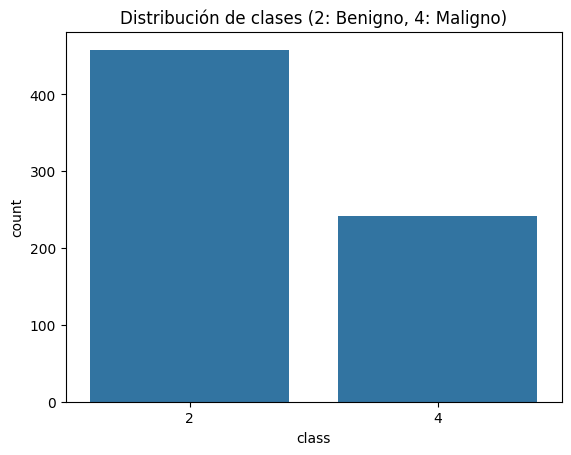

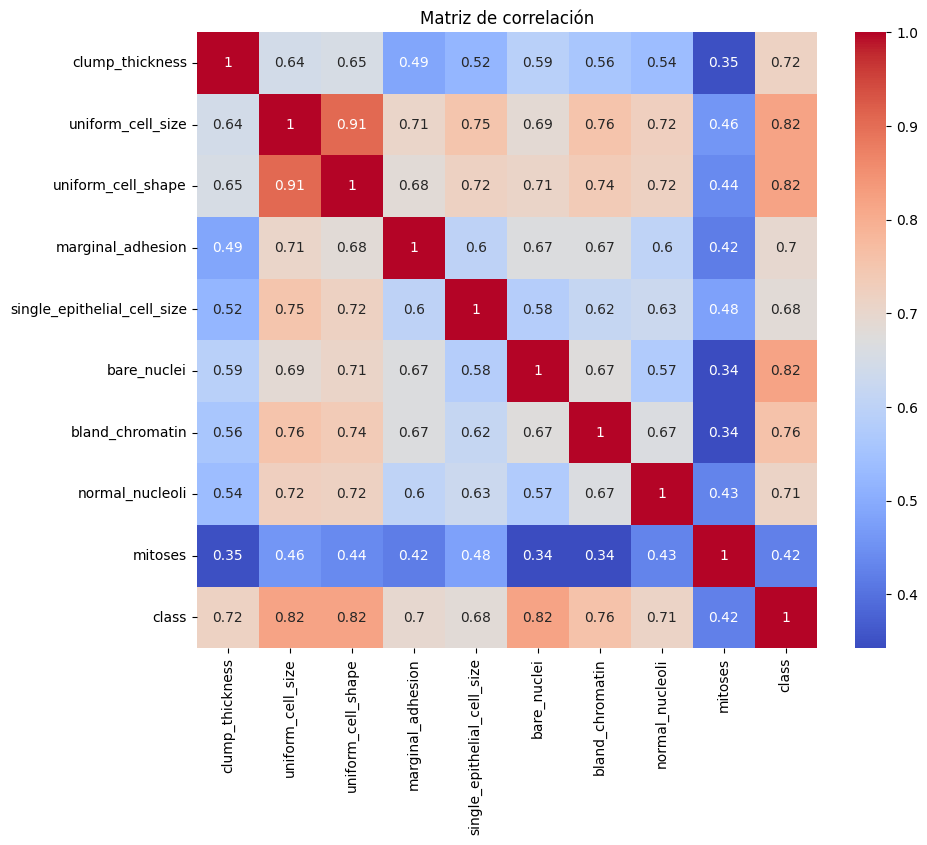

In [4]:
# Ver la distribución de clases
sns.countplot(x="class", data=df)
plt.title("Distribución de clases (2: Benigno, 4: Maligno)")
plt.show()

# Correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()


In [5]:
# Separar variables predictoras y objetivo
X = df.drop("class", axis=1)
y = df["class"]

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


Árbol de Decisión - Reporte de Clasificación:

              precision    recall  f1-score   support

           2       0.96      0.97      0.96       118
           4       0.93      0.91      0.92        57

    accuracy                           0.95       175
   macro avg       0.94      0.94      0.94       175
weighted avg       0.95      0.95      0.95       175

Matriz de Confusión:
 [[114   4]
 [  5  52]]
Precisión: 0.9485714285714286


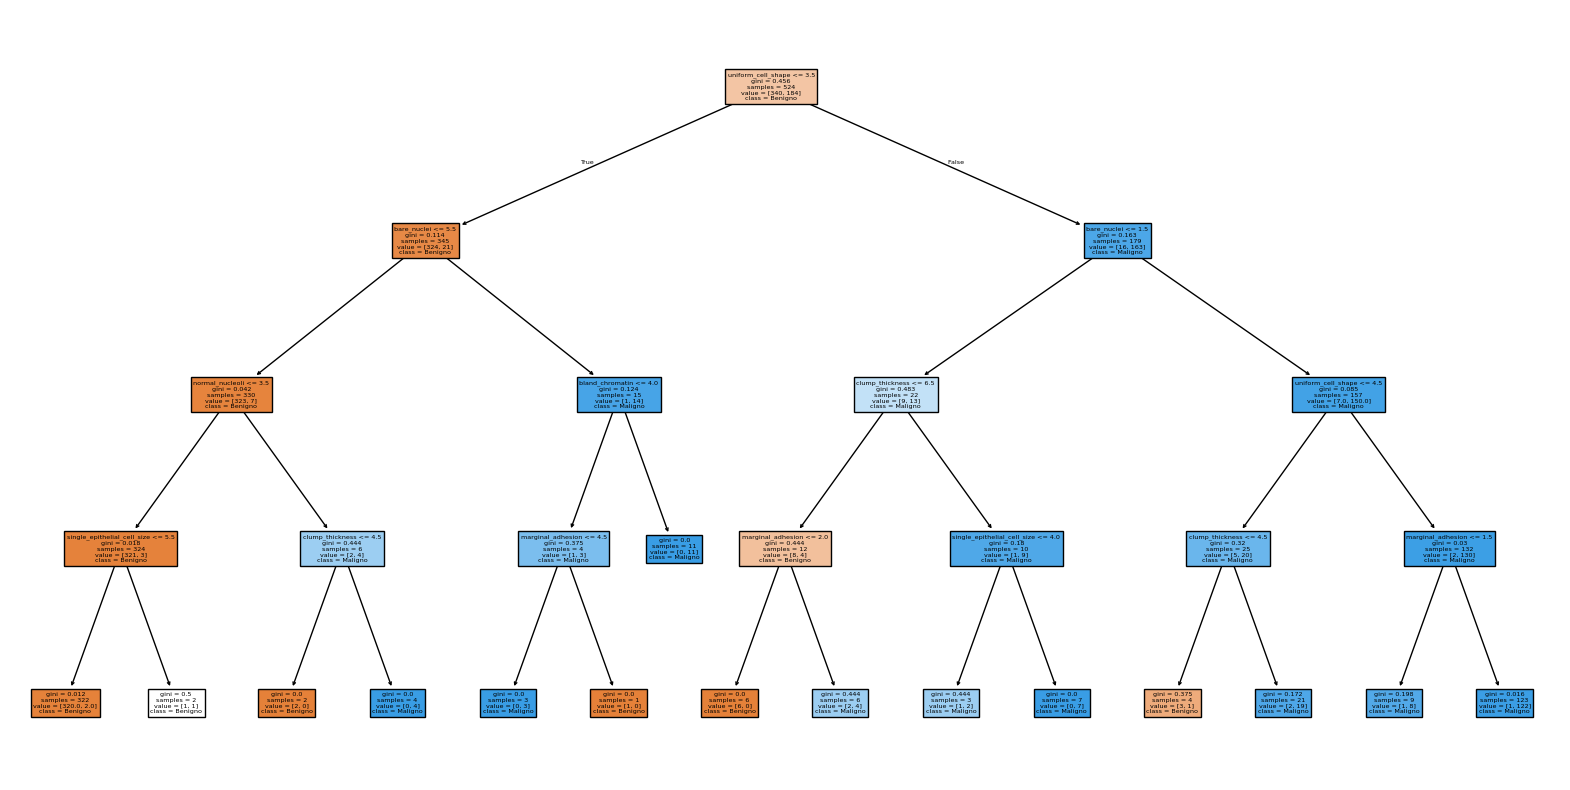

In [6]:
# Entrenamiento del modelo
arbol = DecisionTreeClassifier(max_depth=4, random_state=42)
arbol.fit(X_train, y_train)

# Predicciones
y_pred_arbol = arbol.predict(X_test)

# Métricas
print("Árbol de Decisión - Reporte de Clasificación:\n")
print(classification_report(y_test, y_pred_arbol))
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred_arbol))
print("Precisión:", accuracy_score(y_test, y_pred_arbol))

# Visualización del árbol
plt.figure(figsize=(20, 10))
plot_tree(arbol, feature_names=X.columns, class_names=["Benigno", "Maligno"], filled=True)
plt.show()


In [7]:
# Entrenamiento del modelo
bosque = RandomForestClassifier(n_estimators=100, random_state=42)
bosque.fit(X_train, y_train)

# Predicciones
y_pred_bosque = bosque.predict(X_test)

# Métricas
print("Bosques Aleatorios - Reporte de Clasificación:\n")
print(classification_report(y_test, y_pred_bosque))
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred_bosque))
print("Precisión:", accuracy_score(y_test, y_pred_bosque))


Bosques Aleatorios - Reporte de Clasificación:

              precision    recall  f1-score   support

           2       0.97      0.97      0.97       118
           4       0.95      0.95      0.95        57

    accuracy                           0.97       175
   macro avg       0.96      0.96      0.96       175
weighted avg       0.97      0.97      0.97       175

Matriz de Confusión:
 [[115   3]
 [  3  54]]
Precisión: 0.9657142857142857


En este laboratorio aprendí a usar los árboles de decisión y los bosques aleatorios para clasificar datos de cáncer de mama. Primero limpié y preparé los datos, separando la variable que quería predecir. Luego entrené un árbol de decisión y revisé qué tan bien funcionaba. Después usé un modelo de bosque aleatorio y comparé los resultados. Me di cuenta de que el bosque aleatorio tuvo mejores resultados porque combina varios árboles y eso lo hace más preciso. En general, esta práctica me ayudó a entender mejor cómo funcionan estos modelos y cómo usarlos en casos reales.